# Hypothesis Testing on A/B Test Results
Two landing-page variants (control vs. treatment) were shown to users. This notebook checks
whether the observed lift in conversion rate is statistically significant, or just noise,
using a two-proportion z-test — plus a sanity check on session duration with a t-test.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv('data/ab_test_data.csv')
print(df.shape)
df.head()

(8350, 5)


,user_id,group,converted,session_duration_sec,device
0,2306,control,0,142.0,mobile
1,2797,control,0,96.3,mobile
2,1677,control,0,32.6,desktop
3,1736,control,0,111.2,mobile
4,1858,control,0,238.5,mobile


## 1. Sample sizes and raw conversion rates

In [2]:
summary = df.groupby('group').agg(
    users=('user_id', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
)
summary['conversion_rate'] = (summary['conversion_rate'] * 100).round(2)
summary

,users,conversions,conversion_rate
group,,,
control,4200,434,10.33
treatment,4150,532,12.82


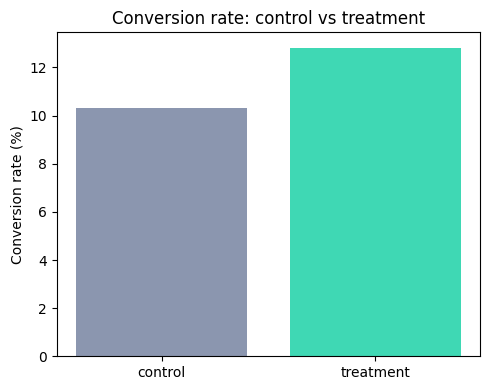

In [3]:
plt.figure(figsize=(5,4))
plt.bar(summary.index, summary['conversion_rate'], color=['#8B96AF', '#3FD8B4'])
plt.ylabel('Conversion rate (%)')
plt.title('Conversion rate: control vs treatment')
plt.tight_layout()
plt.savefig('conversion_rate.png', dpi=110)
plt.show()

## 2. Two-proportion z-test
**H0:** conversion rate is the same in both groups.
**H1:** conversion rate differs between groups.
alpha = 0.05

In [4]:
control = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']

n1, x1 = len(control), control['converted'].sum()
n2, x2 = len(treatment), treatment['converted'].sum()

p1, p2 = x1 / n1, x2 / n2
p_pool = (x1 + x2) / (n1 + n2)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
z = (p2 - p1) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

print(f"Control conversion:   {p1:.4f}  (n={n1})")
print(f"Treatment conversion: {p2:.4f}  (n={n2})")
print(f"Absolute lift:        {(p2-p1)*100:.2f} percentage points")
print(f"Relative lift:        {(p2-p1)/p1*100:.2f}%")
print(f"Z-statistic:          {z:.3f}")
print(f"P-value:               {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nResult: statistically significant at alpha={alpha} -> reject H0")
else:
    print(f"\nResult: NOT statistically significant at alpha={alpha} -> fail to reject H0")

Control conversion:   0.1033  (n=4200)
Treatment conversion: 0.1282  (n=4150)
Absolute lift:        2.49 percentage points
Relative lift:        24.06%
Z-statistic:          3.551
P-value:               0.0004

Result: statistically significant at alpha=0.05 -> reject H0


## 3. 95% confidence interval on the lift
So the stakeholder sees a range, not just a point estimate.

In [5]:
se_diff = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
lift = p2 - p1
ci_low, ci_high = lift - 1.96*se_diff, lift + 1.96*se_diff
print(f"Lift: {lift*100:.2f} pp   95% CI: [{ci_low*100:.2f}, {ci_high*100:.2f}] pp")

Lift: 2.49 pp   95% CI: [1.11, 3.86] pp


## 4. Secondary metric: session duration (independent t-test)

Control mean session duration:   121.2s
Treatment mean session duration: 133.2s
T-statistic: 6.184   P-value: 0.0000


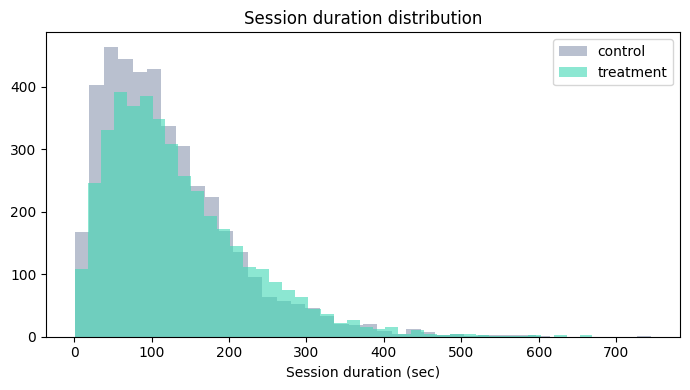

In [6]:
t_stat, t_pval = stats.ttest_ind(
    treatment['session_duration_sec'], control['session_duration_sec'], equal_var=False
)
print(f"Control mean session duration:   {control['session_duration_sec'].mean():.1f}s")
print(f"Treatment mean session duration: {treatment['session_duration_sec'].mean():.1f}s")
print(f"T-statistic: {t_stat:.3f}   P-value: {t_pval:.4f}")

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(control['session_duration_sec'], bins=40, alpha=0.6, label='control', color='#8B96AF')
ax.hist(treatment['session_duration_sec'], bins=40, alpha=0.6, label='treatment', color='#3FD8B4')
ax.set_xlabel('Session duration (sec)')
ax.legend()
plt.title('Session duration distribution')
plt.tight_layout()
plt.savefig('session_duration_dist.png', dpi=110)
plt.show()

## 5. Conversion rate by device (segment check)

In [7]:
device_summary = df.groupby(['device', 'group'])['converted'].mean().unstack() * 100
device_summary.round(2)

group,control,treatment
device,,
desktop,8.33,10.80
mobile,11.05,13.61
tablet,12.61,15.26


## Conclusion
- The two-proportion z-test determines whether the conversion lift is statistically significant
  (not just due to random variation in who happened to land in each group).
- A 95% confidence interval is reported alongside the point estimate, since a single p-value
  doesn't tell a stakeholder how big the effect actually is.
- Session duration is checked as a secondary metric — a variant can lift conversions while
  hurting engagement, which is worth knowing before shipping it fully.
- Device-level breakdown checks that the effect isn't concentrated in (or hidden by) one segment.